In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

In [ ]:
df = pd.read_csv("/content/FE-GWP1_dataset_Prob5.csv")
df = df.iloc[:, 0].str.split(",", expand=True)
df.columns = ["Period", "X", "Y", "Z"]
df = df.set_index(['Period'])
data = df[['X', 'Y', 'Z']].astype(float)

In [ ]:
data

,X,Y,Z
Period,,,
1,0.082217,0.577180,-0.312377
2,0.078359,-0.317703,-0.555119
3,1.379785,0.837258,-0.991766
4,2.834353,1.689486,-1.889942
5,2.284564,1.124723,-2.199465
...,...,...,...
296,-4.568966,-1.401228,4.534195
297,-3.549296,-1.449302,3.404539
298,-3.596441,-1.169467,3.383304


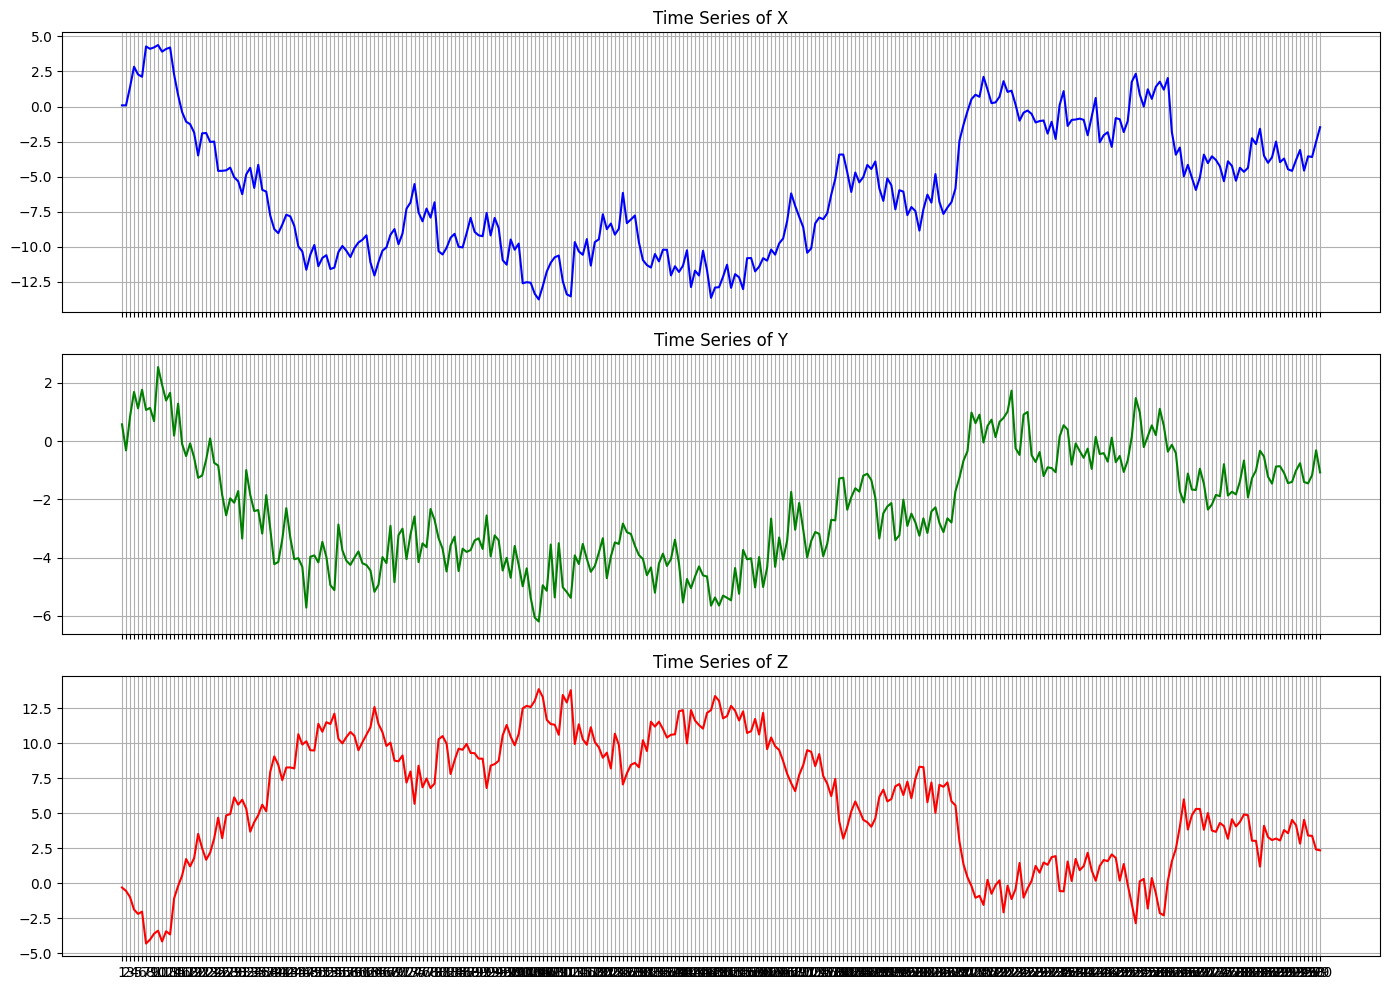

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

axes[0].plot(data['X'], color='blue')
axes[0].set_title('Time Series of X')
axes[0].grid(True)

axes[1].plot(data['Y'], color='green')
axes[1].set_title('Time Series of Y')
axes[1].grid(True)

axes[2].plot(data['Z'], color='red')
axes[2].set_title('Time Series of Z')
axes[2].grid(True)

plt.tight_layout()
plt.show()

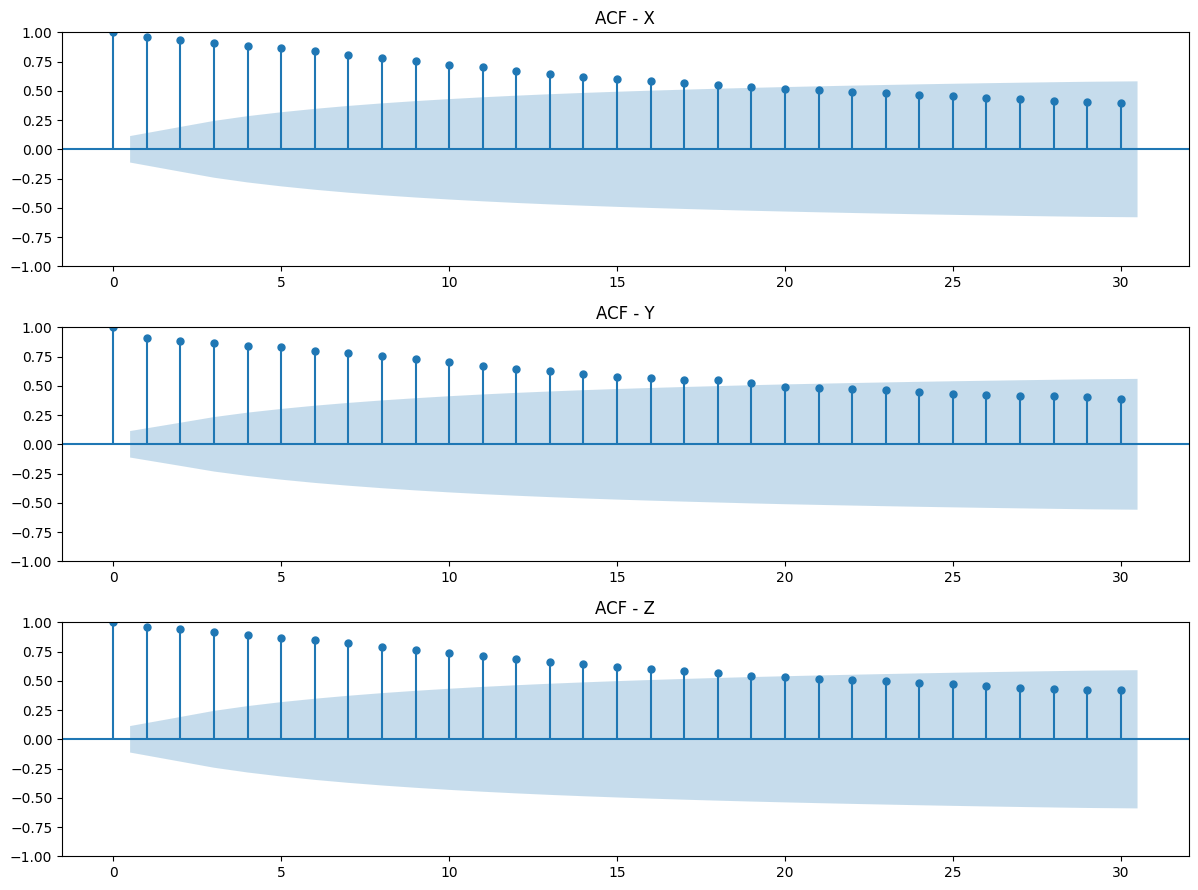

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(3,1, figsize=(12,9))

plot_acf(data['X'], lags=30, ax=axes[0])
axes[0].set_title("ACF - X")

plot_acf(data['Y'], lags=30, ax=axes[1])
axes[1].set_title("ACF - Y")

plot_acf(data['Z'], lags=30, ax=axes[2])
axes[2].set_title("ACF - Z")

plt.tight_layout()
plt.show()

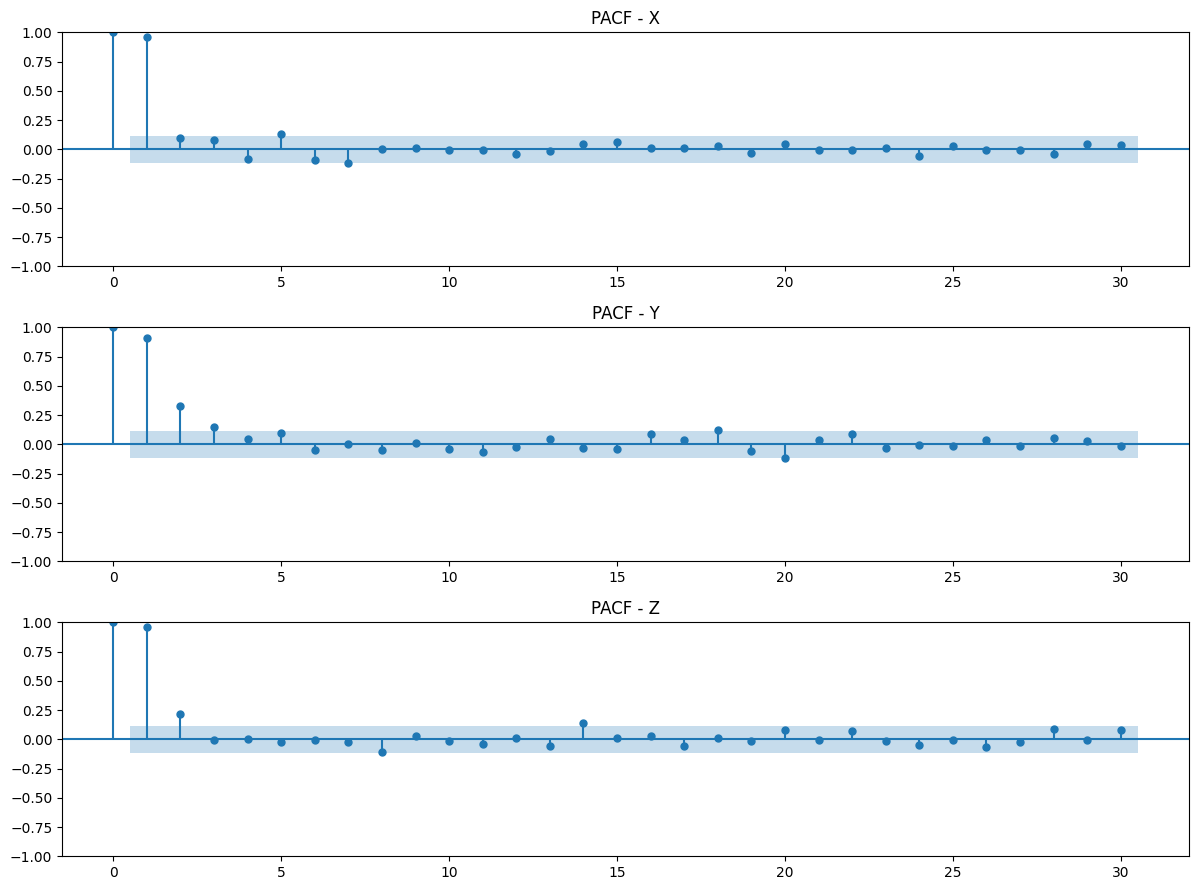

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, axes = plt.subplots(3,1, figsize=(12,9))

plot_pacf(data['X'], lags=30, ax=axes[0], method='ywm')
axes[0].set_title("PACF - X")

plot_pacf(data['Y'], lags=30, ax=axes[1], method='ywm')
axes[1].set_title("PACF - Y")

plot_pacf(data['Z'], lags=30, ax=axes[2], method='ywm')
axes[2].set_title("PACF - Z")

plt.tight_layout()
plt.show()

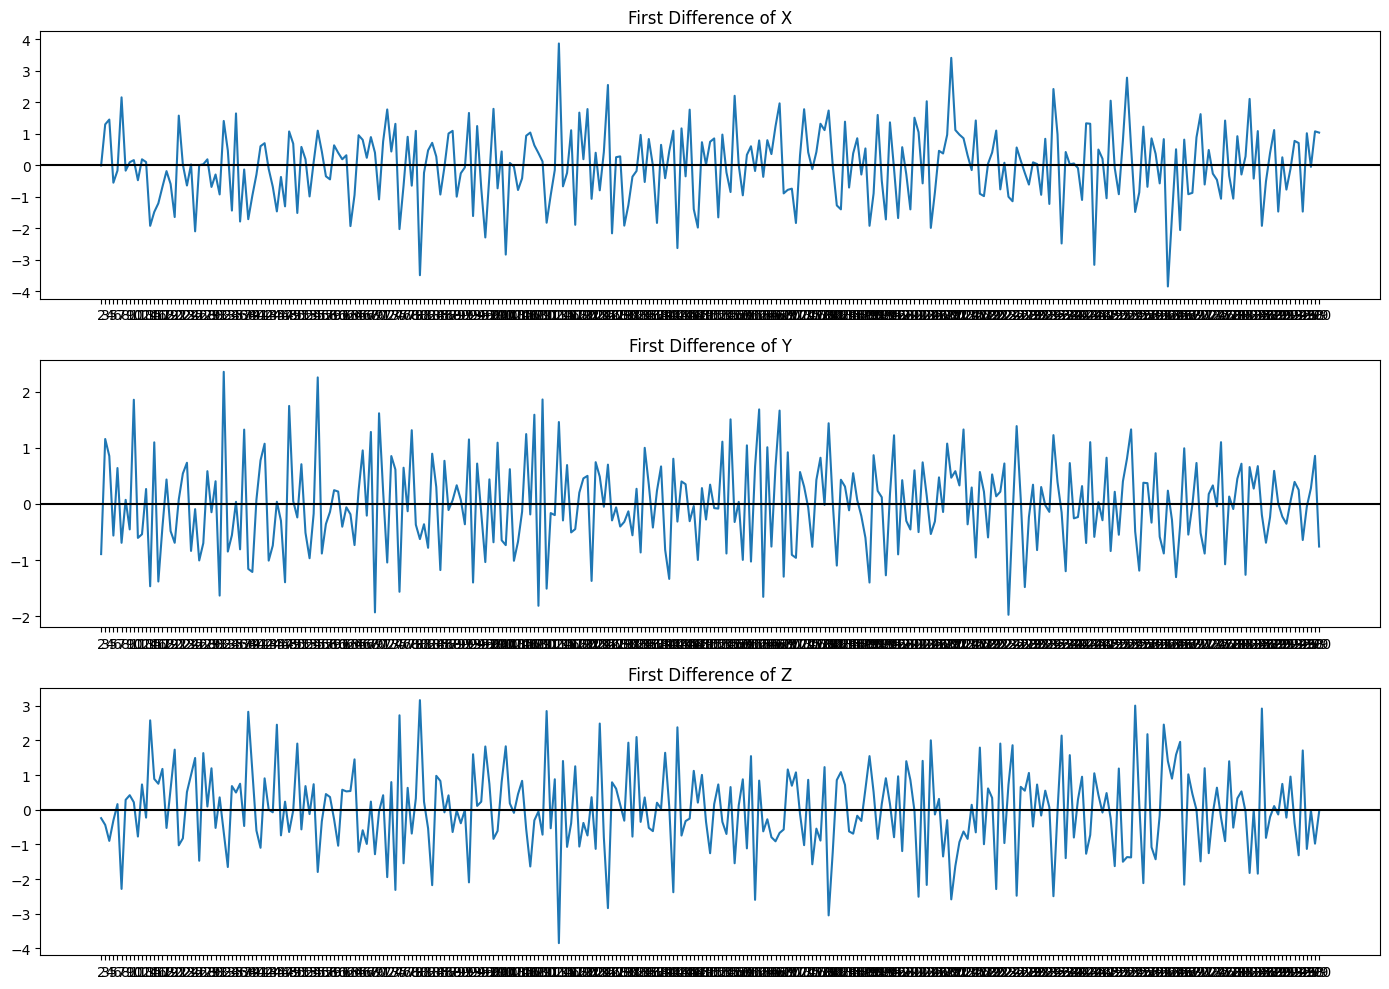

In [ ]:
diff=data.diff().dropna()

fig,ax=plt.subplots(3,1,figsize=(14,10))

for i,col in enumerate(diff.columns):

    ax[i].plot(diff[col])
    ax[i].axhline(0,color='black')
    ax[i].set_title(f"First Difference of {col}")

plt.tight_layout()
plt.show()

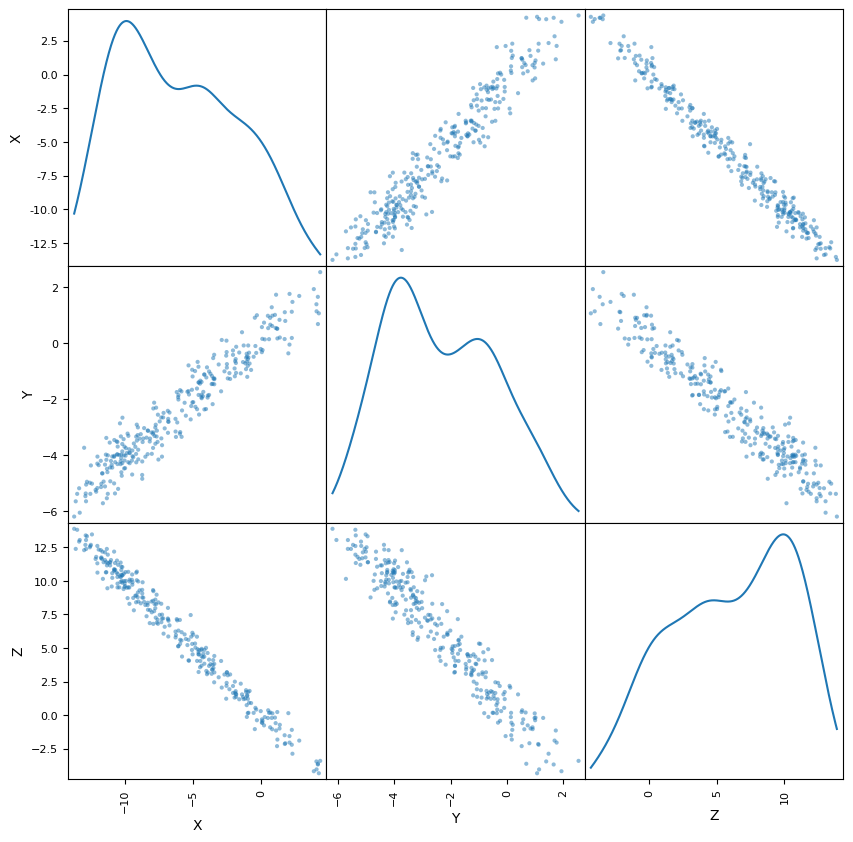

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(data,
               figsize=(10,10),
               diagonal='kde')

plt.show()

In [ ]:
print("="*60)
print("ADF UNIT ROOT TEST")
print("="*60)

results=[]

for col in data.columns:

    adf=adfuller(data[col])

    results.append([
        col,
        adf[0],
        adf[1]
    ])

    print(f"\nVariable : {col}")
    print(f"ADF Statistic : {adf[0]:.4f}")
    print(f"P-value : {adf[1]:.4f}")

    for key,val in adf[4].items():
        print(f"{key}: {val:.4f}")

    if adf[1]<0.05:
        print("Stationary")
    else:
        print("Non-Stationary")

ADF UNIT ROOT TEST

Variable : X
ADF Statistic : -2.4862
P-value : 0.1189
1%: -3.4529
5%: -2.8715
10%: -2.5721
Non-Stationary

Variable : Y
ADF Statistic : -2.0803
P-value : 0.2525
1%: -3.4527
5%: -2.8714
10%: -2.5720
Non-Stationary

Variable : Z
ADF Statistic : -1.9667
P-value : 0.3014
1%: -3.4525
5%: -2.8713
10%: -2.5720
Non-Stationary


In [ ]:
print("="*60)
print("ADF AFTER FIRST DIFFERENCING")
print("="*60)

for col in diff.columns:

    adf=adfuller(diff[col])

    print("\n",col)
    print("ADF Statistic:",round(adf[0],4))
    print("P-value:",round(adf[1],4))

    if adf[1]<0.05:
        print("Stationary")
    else:
        print("Still Non-stationary")

ADF AFTER FIRST DIFFERENCING

 X
ADF Statistic: -10.3397
P-value: 0.0
Stationary

 Y
ADF Statistic: -12.0124
P-value: 0.0
Stationary

 Z
ADF Statistic: -22.5105
P-value: 0.0
Stationary


In [ ]:
johan=coint_johansen(data,
                     det_order=0,
                     k_ar_diff=1)

In [ ]:
trace_table=pd.DataFrame({

'Rank':[0,1,2],
'Trace Statistic':johan.lr1,
'90% CV':johan.cvt[:,0],
'95% CV':johan.cvt[:,1],
'99% CV':johan.cvt[:,2]

})

print(trace_table)

   Rank  Trace Statistic   90% CV   95% CV   99% CV
0     0       262.065729  27.0669  29.7961  35.4628
1     1       128.769652  13.4294  15.4943  19.9349
2     2         3.925153   2.7055   3.8415   6.6349


In [ ]:
maxeig_table=pd.DataFrame({

'Rank':[0,1,2],
'Max Eigen Statistic':johan.lr2,
'90% CV':johan.cvm[:,0],
'95% CV':johan.cvm[:,1],
'99% CV':johan.cvm[:,2]

})

print(maxeig_table)

   Rank  Max Eigen Statistic   90% CV   95% CV   99% CV
0     0           133.296077  18.8928  21.1314  25.8650
1     1           124.844499  12.2971  14.2639  18.5200
2     2             3.925153   2.7055   3.8415   6.6349


In [ ]:
rank=0

for i in range(len(johan.lr1)):

    if johan.lr1[i]>johan.cvt[i,1]:
        rank+=1

print("Estimated Cointegration Rank =",rank)

Estimated Cointegration Rank = 3


In [ ]:
if rank==0:
    rank=1

vecm=VECM(data,
          coint_rank=rank,
          k_ar_diff=1,
          deterministic='co')

vecm_fit=vecm.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation X
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1312      0.109     -1.199      0.230      -0.346       0.083
L1.X           0.0609      0.102      0.600      0.549      -0.138       0.260
L1.Y           0.1843      0.124      1.489      0.137      -0.058       0.427
L1.Z           0.1857      0.101      1.837      0.066      -0.012       0.384
Det. terms outside the coint. relation & lagged endog. parameters for equation Y
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0827      0.062      1.326      0.185      -0.040       0.205
L1.X          -0.0247      0.058     -0.426      0.670      -0.138       0.089
L1.Y           0.0719      0.071      1.019     

In [ ]:
alpha=pd.DataFrame(vecm_fit.alpha,
                   index=data.columns)

print(alpha)

          0         1         2
X -0.566819  0.033765 -0.529526
Y  0.142771 -1.024512 -0.271879
Z -0.465338 -0.060994 -0.520336


In [ ]:
beta=pd.DataFrame(vecm_fit.beta,
                  index=data.columns)

print(beta)

              0             1             2
X  1.000000e+00  2.091527e-17 -1.644620e-16
Y  1.272325e-17  1.000000e+00  2.152251e-17
Z -6.476355e-18 -3.026151e-17  1.000000e+00


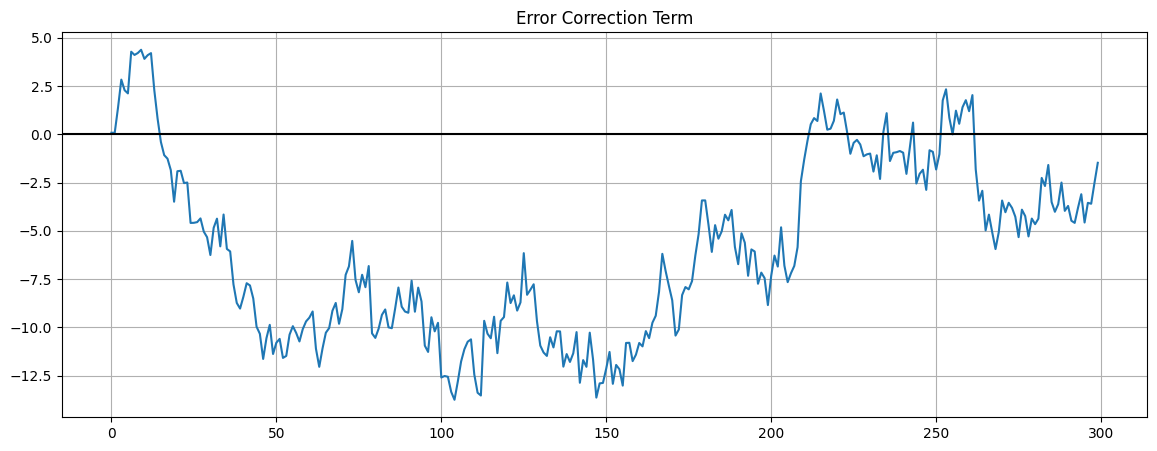

In [ ]:
beta_vector=vecm_fit.beta[:,0]

ect=np.dot(data,beta_vector)

plt.figure(figsize=(14,5))

plt.plot(ect)

plt.axhline(0,color='black')

plt.title("Error Correction Term")

plt.grid(True)

plt.show()

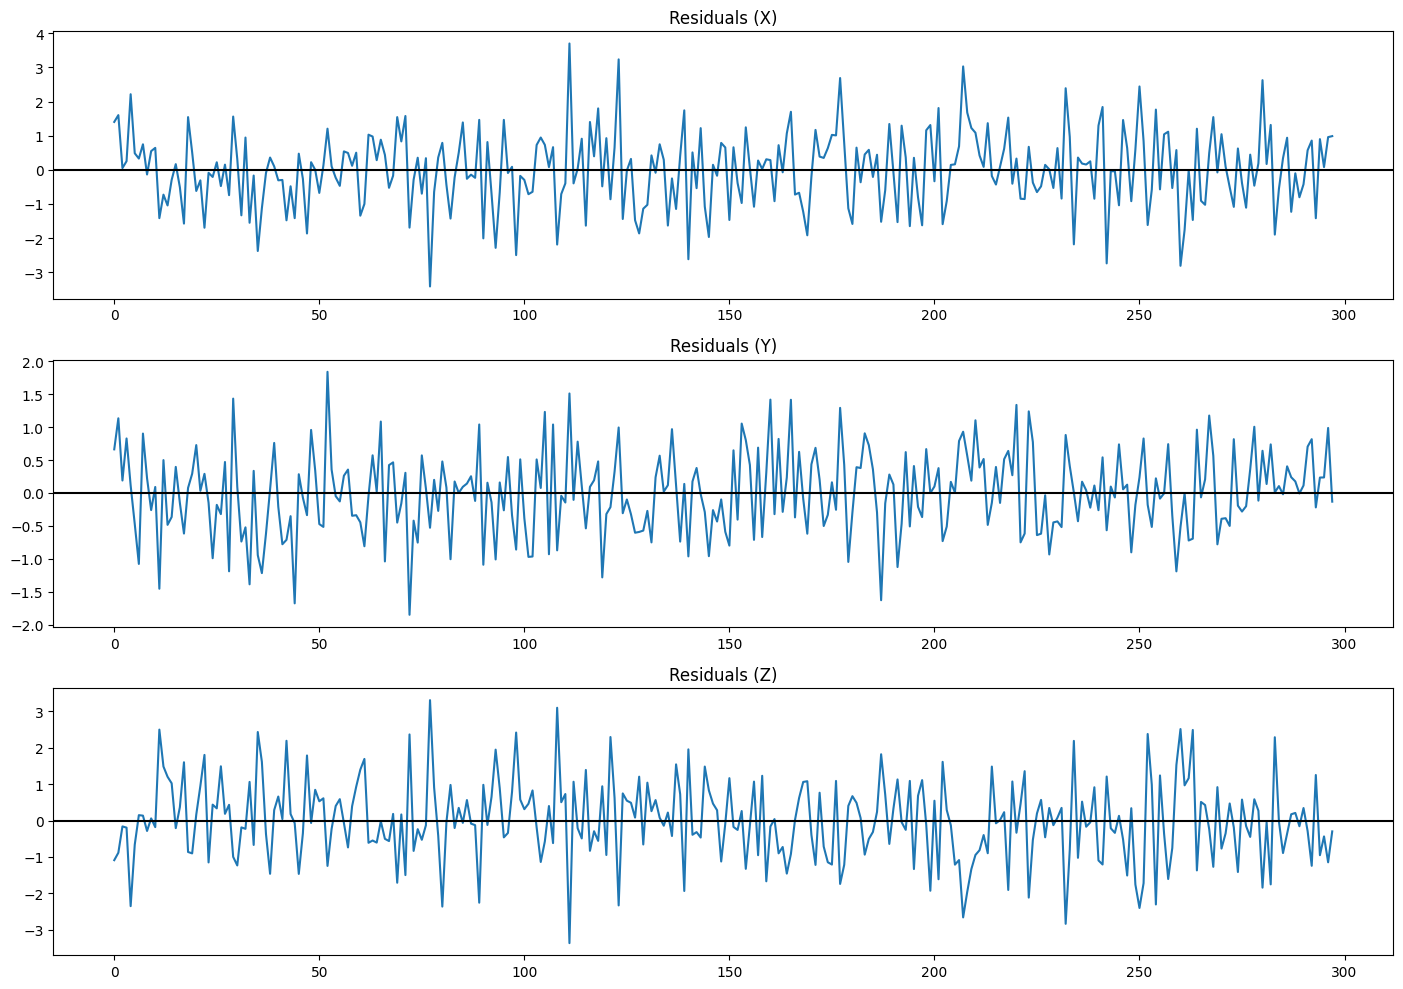

In [ ]:
residuals=vecm_fit.resid

fig,ax=plt.subplots(3,1,figsize=(14,10))

for i,col in enumerate(data.columns):

    ax[i].plot(residuals[:,i])

    ax[i].axhline(0,color='black')

    ax[i].set_title(f"Residuals ({col})")

plt.tight_layout()

plt.show()